# 01. DP2 and RSP reminder

Run at RSP

**Goal:** a 40-minute refresher on how RSP/DP2 data access is organized.

**Covers:**
- schema reminder
- LSDB vs TAP vs Butler vs SIA
- plotting maps (footprint, survey property map)
- how tables join: ID-join vs coordinate-crossmatch
- cone search / filtering, TAP vs LSDB timed
- light curves: science / DIA / forced photometry
- quality flags and extendedness

**Field used throughout:** `Rubin_SV_225_-40` (RA=225.0, Dec=-39.5, r=1.9 deg) (1958 visits / 29 nights / 238 d baseline).

## 0. Setup

In [38]:
import re
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from lsst.rsp import RSPDiscovery
from lsst.daf.butler import Butler
from lsst.images.serialization import read_archive
import lsst.afw.display as afw_display
from lsst.utils.plotting import get_multiband_plot_colors, get_multiband_plot_symbols

import lsdb
from upath import UPath

In [39]:
discovery = RSPDiscovery("dp2")
tap = discovery.get_tap_client()
butler = Butler("dp2", collections="dp2")
sia = discovery.get_sia_client()

lsdb_base = UPath("/rubin/lsdb_data/dp2")

afw_display.setDefaultBackend("matplotlib")

filter_colors = get_multiband_plot_colors()
filter_names = list(filter_colors.keys())
filter_symbols = get_multiband_plot_symbols()

Field and object used throughout this notebook.

In [40]:
# Rubin_SV_225_-40
field_ra, field_dec, field_rad = 225.0, -39.5, 1.9

# RR Lyrae inside the field (Gaia DR3 6005347144427786624)
star_ra, star_dec = 226.7244283498404, -40.30405425755786
star_diaObjectId = 743582465276248313
star_period = 0.5180638410804721  # days

## 1. Schema reminder

**Table grain:**
- `Object` — one row per detected object, forced photometry on `deep_coadd` (786M rows)
- `Source` — one row per detection per visit
- `ForcedSource` — one row per Object per visit, forced photometry (direct + difference)
- `DiaObject` — one row per DIA-detected object, light-curve summary stats (232M rows)
- `DiaSource` — one row per >5σ difference-image detection
- `ForcedSourceOnDiaObject` — one row per DiaObject per visit, forced photometry
- `Visit`, `VisitDetector` — per-exposure / per-detector metadata
- `CoaddPatches` — deep_coadd tract/patch metadata
- `SSObject`, `SSSource`, `mpc_orbits`, `*_identifications` — Solar System
- `ShearObject`, `IsolatedStarStellarMotions` — specialized derived catalogs

Full schema: [sdm-schemas.lsst.io](https://sdm-schemas.lsst.io/dp2.html)

In [41]:
query = ("SELECT column_name, datatype, description, unit "
          "FROM tap_schema.columns WHERE table_name = 'dp2.Object'")
job = tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
assert job.phase == 'COMPLETED'
obj_schema = job.fetch_result().to_table()
job.delete()
print(f"dp2.Object has {len(obj_schema)} columns")

dp2.Object has 1248 columns


Searching columns by pattern, e.g. `cModelMag`
Beware: columns with similar (or even the same!) names in different tables may and do have different meaning and values!

In [42]:
for col in obj_schema['column_name']:
    if re.search('cModelMag', col):
        print(col)

u_cModelMag
u_cModelMagErr
g_cModelMag
g_cModelMagErr
r_cModelMag
r_cModelMagErr
i_cModelMag
i_cModelMagErr
z_cModelMag
z_cModelMagErr
y_cModelMag
y_cModelMagErr


## 2. Data access services

### 2a. Catalogs — TAP vs LSDB vs Butler

(IMO, Rubin data people are welcome to correct me)

| | TAP | LSDB | Butler |
|---|---|---|---|
| recommended for | exploring/accessing all columns for small-ish samples | crossmatching, pre-filtering | whole visit/tract dumps |
| coverage | all 16 `dp2.*` tables | `Object`, `DiaObject`, `object_photoz` only, `Source` tables included as nested columns | all tables, but no filtering |
| filtering | ADQL `WHERE`, joins | `.cone_search()`, `.query()` | dataId / `where=` only |
| speed | network + Qserv | local HATS parquet, lazy operations -> faster | fast, but no server-side cuts |

Same cone search, three ways.

In [43]:
query = ("SELECT objectId, coord_ra, coord_dec, r_psfMag, refExtendedness "
          "FROM dp2.Object WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), "
          f"CIRCLE('ICRS', {field_ra}, {field_dec}, 0.05)) = 1")
job = tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
assert job.phase == 'COMPLETED'
tap_result = job.fetch_result().to_table()
job.delete()
print(f"TAP: {len(tap_result)} objects")

TAP: 2859 objects


In [44]:
tap_result

objectId,coord_ra,coord_dec,r_psfMag,refExtendedness
,deg,deg,mag,
int64,float64,float64,float32,float32
744857555167099122,224.97332206356,-39.45671604538594,24.0146,1.0
744857555167099121,224.97249147858696,-39.456250897612314,24.3741,0.0
744857555167099119,224.9746136894389,-39.46168274369201,23.4206,--
744857555167099118,224.97695643728207,-39.46526660937529,21.7718,1.0
744857555167099117,224.9739689444279,-39.45738281526232,21.9078,1.0
744857555167099136,224.97642143651026,-39.456423383718025,24.9311,1.0
744857555167099140,224.97224657008528,-39.45793309542609,24.923,1.0
744857555167099137,224.97200164727542,-39.46370308245514,27.2706,1.0


In [45]:
object_cat = lsdb.open_catalog(lsdb_base / "object_collection",
                               columns=["objectId", "coord_ra", "coord_dec",
                                        "r_psfMag", "refExtendedness"])
lsdb_result = object_cat.cone_search(ra=field_ra, dec=field_dec,
                                     radius_arcsec=0.05 * 3600).compute()
print(f"LSDB: {len(lsdb_result)} objects")

Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

LSDB: 2859 objects


In [46]:
lsdb_result

,objectId,coord_ra,coord_dec,r_psfMag,refExtendedness
_healpix_29,,,,,
3098704584297793496,744857486447616456,225.027833,-39.54431,24.319386,1.0
3098704584319182228,744857486447616453,225.028795,-39.544307,23.502159,0.0
...,...,...,...,...,...
3098728714236838592,744857555167099685,224.971932,-39.455067,24.257969,1.0
3098728714258465169,744857555167099684,224.972299,-39.454996,26.926298,1.0


Butler: whole tracts, fluxes only, no coordinate filter.

In [47]:
bwhere = "tract.region OVERLAPS POINT(:ra, :dec)"
refs = butler.query_datasets("object", where=bwhere,
                             bind={"ra": field_ra, "dec": field_dec})
butler_tbl = butler.get(refs[0], parameters={
    'columns': ['objectId', 'coord_ra', 'coord_dec', 'r_psfFlux', 'refExtendedness']})
print(f"Butler: {len(refs)} tract(s), {len(butler_tbl)} objects in first tract (whole tract, not just the cone)")

Butler: 1 tract(s), 764697 objects in first tract (whole tract, not just the cone)


In [48]:
butler_tbl

objectId,coord_ra,coord_dec,r_psfFlux,refExtendedness
int64,float64,float64,float32,float32
744854531510108592,225.6596853501632,-40.163528190716924,476.97726,1.0
744854531510108596,225.64238653278073,-40.16239787220804,366.98676,0.0
744854531510108605,225.69740513929037,-40.160067812929924,372.59607,0.0
744854531510108623,225.67195454216989,-40.15339885056975,120.32895,0.0
744854531510108634,225.71236047440917,-40.149854130910136,5663.9956,0.0
744854531510108643,225.68012247779583,-40.14865621839664,153.77106,0.0
744854531510108652,225.68875176855803,-40.14631724069316,564.84705,1.0
744854531510108655,225.66672295962056,-40.14608184948544,167.19357,1.0
744854531510108660,225.69538574061423,-40.144192015061286,2137.2256,0.0


### 2b. Images — Butler vs SIA vs TAP(ObsCore) vs cutouts

| | Butler | SIA | TAP / ObsCore | cutouts |
|---|---|---|---|---|
| recommended for | image access (default) | standardized IVOA metadata search | same metadata as SIA, via ADQL | small pixel regions, server-side |
| calib levels | `raw`(1) / `visit_image`(2) / `deep_coadd`,`template_coadd`,`difference_image`(3) | same | same (`dataproduct_subtype`) | any of the above |

Retrieve and display one `deep_coadd` via the Butler (recommended path). 


In [49]:
iwhere = "band.name = 'r' AND patch.region OVERLAPS POINT(:ra, :dec)"
refs = butler.query_datasets("deep_coadd", where=iwhere,
                             bind={"ra": field_ra, "dec": field_dec})

In [50]:
coadd = butler.get(refs[0])
coadd.apply_background('pretty')

In [51]:
coadd

<CellCoadd([y=11850:15150, x=8850:12150], tract=3533)>

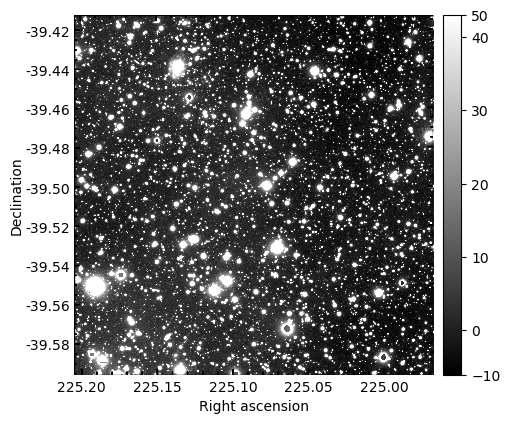

In [52]:
fig, ax = plt.subplots(figsize=(5, 5))
display = afw_display.Display(frame=fig)
display.scale('linear', 'zscale')
display.image(coadd.image)
plt.show()

Same image via SIA: metadata search, then pixels via datalink.

In [53]:
sia_results = sia.search(pos=(field_ra, field_dec, 0.0003), calib_level=3,
                         dpsubtype='lsst.deep_coadd')
tx = np.where(np.array(sia_results['lsst_band']) == 'r')[0]

In [54]:
rec = sia_results.getrecord(int(tx[0]))
dl = discovery.get_datalink_results(rec)
image_url = dl.getrecord(0).get('access_url')
coadd_sia = read_archive(image_url)

In [55]:
coadd_sia

<CellCoadd([y=11850:15150, x=8850:12150], tract=3533)>

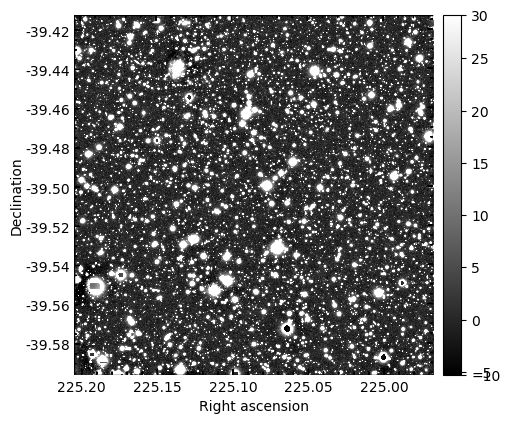

In [56]:
fig, ax = plt.subplots(figsize=(5, 5))
display = afw_display.Display(frame=fig)
display.scale('linear', 'zscale')
display.image(coadd_sia.image)
plt.show()

Same metadata via TAP on `ivoa.ObsCore`.

In [57]:
oquery = ("SELECT * FROM ivoa.ObsCore WHERE CONTAINS(POINT('ICRS', {}, {}), s_region) = 1 "
           "AND obs_collection = 'LSST.DP2' AND dataproduct_subtype = 'lsst.deep_coadd' "
           "AND lsst_band = 'r'").format(field_ra, field_dec)
job = tap.submit_job(oquery)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
assert job.phase == 'COMPLETED'
obscore_result = job.fetch_result().to_table()
job.delete()
print(f"ObsCore/TAP: {len(obscore_result)} matching image(s)")

ObsCore/TAP: 1 matching image(s)


**Cutouts:** server-side pixel subsets, avoids downloading a full image. Not run here; see `103_6`/`103_7`.

## 3. Plotting the maps

#### LSDB `plot_pixels`: HATS partition boundaries, smaller = denser. Works on any subselection, can be used for your own collections.

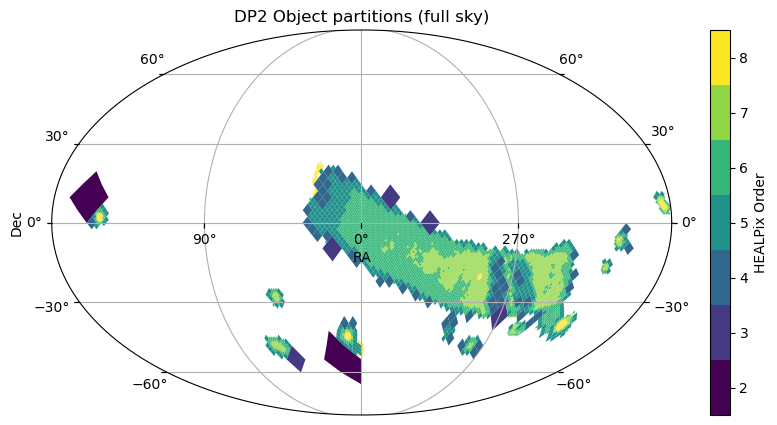

In [58]:
fig, ax = object_cat.plot_pixels(plot_title="DP2 Object partitions (full sky)")
plt.show()

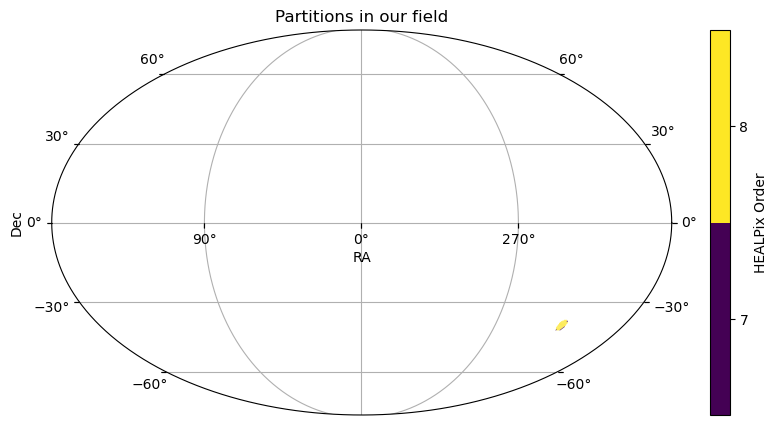

In [59]:
field_cat = object_cat.cone_search(ra=field_ra, dec=field_dec,
                                   radius_arcsec=field_rad * 3600)
fig, ax = field_cat.plot_pixels(plot_title="Partitions in our field")
plt.show()

#### Survey property map: r-band PSF depth (5σ limit), via Butler. Full sky is slow (~70s) -- reading only nearby coverage pixels.

In [60]:
import hpgeom as hpg
from astropy.coordinates import SkyCoord

cov = butler.get('deepCoadd_psf_maglim_consolidated_map_weighted_mean.coverage',
                 band='r', skymap='lsst_cells_v2')
cov_pix, = np.where(cov.coverage_mask)
cov_ra, cov_dec = hpg.pixel_to_angle(cov.nside_coverage, cov_pix)

c0 = SkyCoord(field_ra * u.deg, field_dec * u.deg)
sep = c0.separation(SkyCoord(cov_ra * u.deg, cov_dec * u.deg)).deg
local_pix = cov_pix[sep <= 6.0]

hspmap = butler.get('deepCoadd_psf_maglim_consolidated_map_weighted_mean',
                    band='r', skymap='lsst_cells_v2',
                    parameters={'pixels': list(local_pix), 'degrade_nside': 4096})
print(f"maglim at field center: {hspmap.get_values_pos(field_ra, field_dec):.2f} mag")

maglim at field center: 26.76 mag


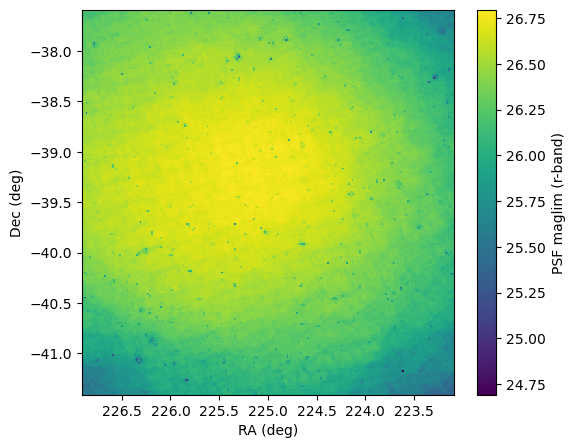

In [61]:
span = field_rad
ra_grid = np.linspace(field_ra - span, field_ra + span, 200)
dec_grid = np.linspace(field_dec - span, field_dec + span, 200)
x, y = np.meshgrid(ra_grid, dec_grid)
values = hspmap.get_values_pos(x, y)
values[values < 0] = np.nan

fig = plt.figure(figsize=(6, 5))
plt.pcolormesh(x, y, values)
plt.xlabel("RA (deg)"); plt.ylabel("Dec (deg)")
plt.colorbar(label="PSF maglim (r-band)")
plt.gca().invert_xaxis()
plt.show()

#### compare map, science, mask at matching scale

A `deep_coadd` patch is ~0.2 deg, not 4 deg, so we can't use the large `psf maglim` image from above. 

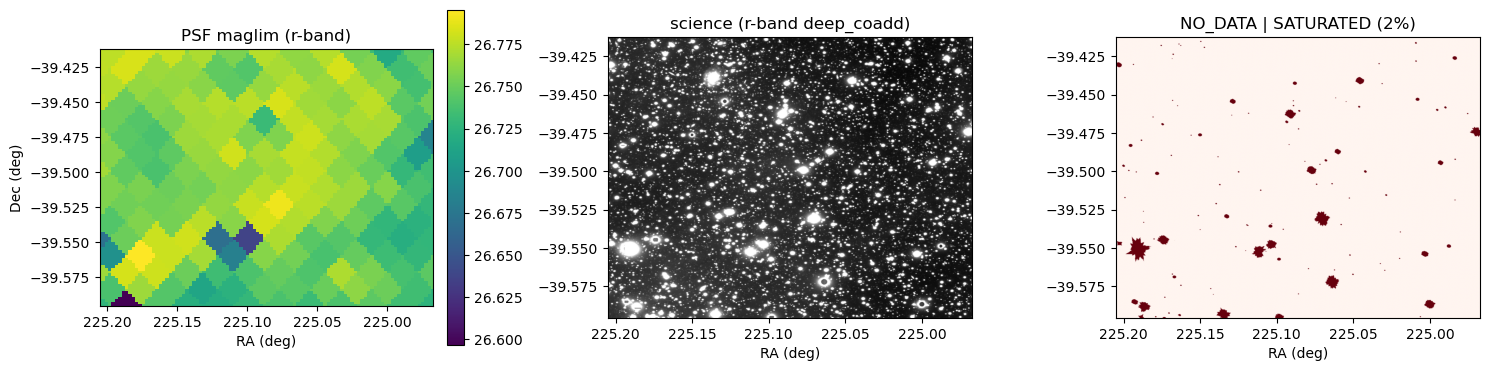

In [62]:
from astropy.visualization import ZScaleInterval, LinearStretch, ImageNormalize

# shared RA/Dec extent from the coadd's WCS
bbox, sky = coadd.bbox, coadd.sky_projection
c00 = sky.pixel_to_sky(x=bbox.x.min, y=bbox.y.min)
c10 = sky.pixel_to_sky(x=bbox.x.max, y=bbox.y.min)
c01 = sky.pixel_to_sky(x=bbox.x.min, y=bbox.y.max)
extent = (c00.ra.degree, c10.ra.degree, c00.dec.degree, c01.dec.degree)

ra_local = np.linspace(extent[0], extent[1], 100)
dec_local = np.linspace(extent[2], extent[3], 100)
xl, yl = np.meshgrid(ra_local, dec_local)
values_local = hspmap.get_values_pos(xl, yl)
values_local[values_local < 0] = np.nan

# DP2 Exclude tier (202_5 Table 1); rest is Retain/Conditional, too broad as a cut
mask = coadd.mask
excluded = mask.get("NO_DATA") | mask.get("SATURATED")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax in axes:
    ax.set_aspect('equal')

im = axes[0].pcolormesh(xl, yl, values_local)
axes[0].set_title("PSF maglim (r-band)")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

norm = ImageNormalize(coadd.image.array, interval=ZScaleInterval(), stretch=LinearStretch())
axes[1].imshow(coadd.image.array, origin='lower', cmap='gray', extent=extent, norm=norm, aspect='equal')
axes[1].set_title("science (r-band deep_coadd)")

axes[2].imshow(excluded, origin='lower', cmap='Reds', extent=extent, vmin=0, vmax=1, aspect='equal')
axes[2].set_title(f"NO_DATA | SATURATED ({excluded.mean():.0%})")

for ax in axes:
    ax.set_xlabel("RA (deg)")
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
axes[0].set_ylabel("Dec (deg)")
plt.tight_layout()
plt.show()

Dark spot on the map = saturated-star cluster in `NO_DATA`/`SATURATED`. Show all of them `202_5` style.

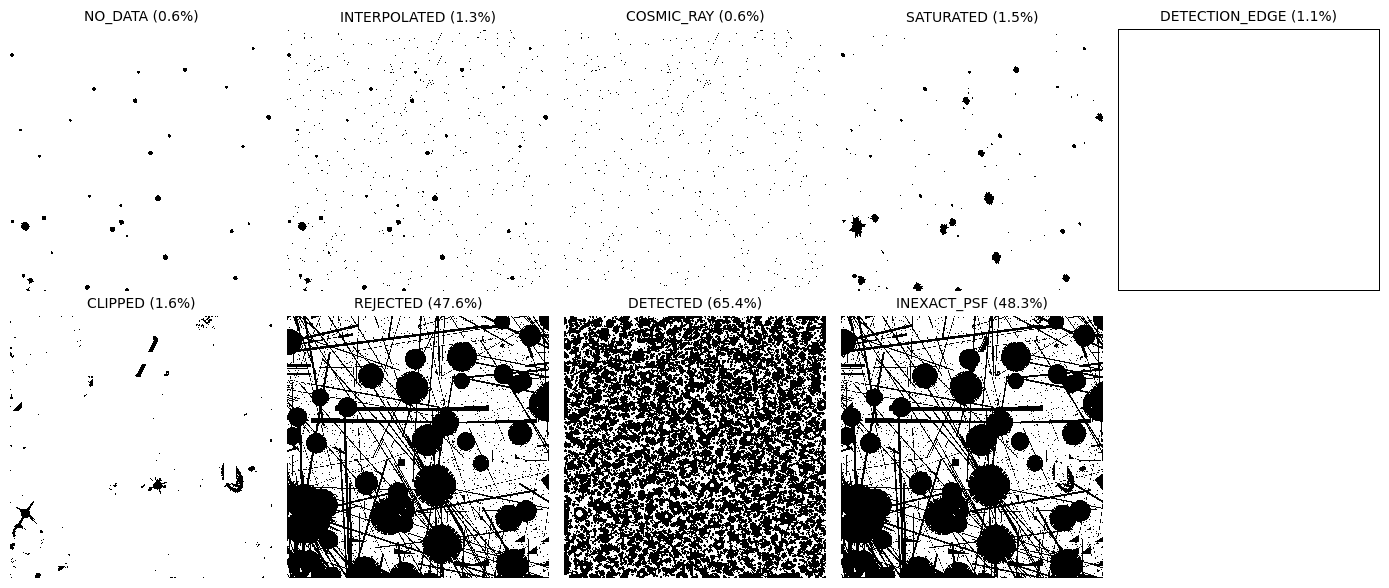

In [63]:
planes = [p.name for p in mask.schema if p is not None]
n_col = 5
n_row = int(np.ceil(len(planes) / n_col))

fig = plt.figure(figsize=(14, 3 * n_row))
for i, name in enumerate(planes):
    ax = fig.add_subplot(n_row, n_col, i + 1)
    arr = mask.get(name)
    ax.imshow(arr, vmin=0, vmax=1, origin='lower', cmap='Greys', interpolation='nearest')
    ax.set_title(f"{name} ({arr.mean():.1%})", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

DP2 `deep_coadd` mask guidance (`202_5`, Table 1):

| Plane | Use |
|---|---|
| `NO_DATA`, `SATURATED` | **Exclude** |
| `INTERPOLATED`, `COSMIC_RAY`, `DETECTED` | Retain |
| `DETECTION_EDGE`, `CLIPPED`, `REJECTED`, `INEXACT_PSF` | Conditional -- `REJECTED`+`INEXACT_PSF` cover ~48% here, too broad as a cut. `DETECTION_EDGE`: 0%, deprecated on `Object`. |

Cutout gallery below uses the narrower `pixelFlags_*Center` planes instead.

## 4. Reading and joining tables

**ID-joins (share a column):**
- `Object.objectId` ↔ `ForcedSource.objectId`
- `DiaObject.diaObjectId` ↔ `DiaSource.diaObjectId` ↔ `ForcedSourceOnDiaObject.diaObjectId`
- `DiaSource.diaSourceId` ↔ `SSSource.diaSourceId`; `SSSource.ssObjectId` ↔ `SSObject.ssObjectId`
- anything with `visit` ↔ `Visit.visit`

**No shared ID — must crossmatch by coordinates:**
- `Object` ↔ `DiaObject` (static-sky detections vs. difference-image detections)

**LSDB shortcut:** forced-photometry ID-joins already done, in nested columns (not all columns preserved).

In [69]:
object_cat_full = lsdb.open_catalog(lsdb_base / "object_collection")
dia_object_cat = lsdb.open_catalog(lsdb_base / "dia_object_collection")
print("Object nested columns:", object_cat_full.nested_columns)
print("DiaObject nested columns:", dia_object_cat.nested_columns)

Object nested columns: ['objectForcedSource']
DiaObject nested columns: ['diaObjectForcedSource', 'diaSource']


Coordinate crossmatch, `Object` ↔ `DiaObject`, 1 arcsec, 0.3 deg sub-cone.

In [65]:
obj_xm = lsdb.open_catalog(lsdb_base / "object_collection",
                          columns=["objectId", "coord_ra", "coord_dec"])
dia_xm = lsdb.open_catalog(lsdb_base / "dia_object_collection",
                          columns=["diaObjectId", "ra", "dec"])
obj_small = obj_xm.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=0.3 * 3600)
dia_small = dia_xm.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=0.3 * 3600)

t0 = time.time()
xmatch = obj_small.crossmatch(dia_small, radius_arcsec=1.0, n_neighbors=1,
                              suffix_method="overlapping_columns")
xmatch_df = xmatch.compute(progress_bar=False)
print(f"{len(xmatch_df)} Object-DiaObject matches in {time.time()-t0:.1f} s")

21836 Object-DiaObject matches in 9.9 s


a) Same crossmatch with nested columns included, 0.05 deg (bounded).

In [66]:
t0 = time.time()
obj_nested_small = object_cat_full.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=0.05 * 3600)
dia_nested_small = dia_object_cat.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=0.05 * 3600)
xmatch_nested = obj_nested_small.crossmatch(dia_nested_small, radius_arcsec=1.0, n_neighbors=1,
                                            suffix_method="overlapping_columns")
xmatch_nested_df = xmatch_nested.compute(progress_bar=False)
print(f"WITH nested cols, 0.05 deg: {len(xmatch_nested_df)} matches in {time.time()-t0:.1f} s")
print(f"(lightweight version at 0.3 deg, 6x the area: {len(xmatch_df)} matches in a few seconds)")

WITH nested cols, 0.05 deg: 565 matches in 54.4 s
(lightweight version at 0.3 deg, 6x the area: 21836 matches in a few seconds)


b) Efficient pattern: crossmatch cheap, then `id_search` to hydrate nested cols only for matches.

In [67]:
matched_ids = xmatch_df['diaObjectId'].tolist()
print(f"{len(matched_ids)} matched diaObjectIds from the lightweight crossmatch")

sample_ids = matched_ids[:50]  # hydrate a working subset, not all of them at once
t0 = time.time()
hydrated = dia_object_cat.id_search(values={"diaObjectId": sample_ids})
hydrated_df = hydrated.compute(progress_bar=False)
print(f"nested light curves for {len(sample_ids)} matched objects: {time.time()-t0:.1f} s")

21836 matched diaObjectIds from the lightweight crossmatch
Searching for diaObjectId=[744856112058073807, 744856112058081637, 744856112058073804, 744856112058084257, 744856112058074742, 744856112058074435, 744856112058073808, 744856112058084326, 744856112058097644, 744856112058077251, 744856112058097646, 744856112058074041, 744856112058075725, 744856112058073393, 744856112058080803, 744856112058084938, 744856112058091120, 744856112058083568, 744856112058094896, 744856112058075506, 744856112058077263, 744856112058075518, 744856112058074195, 744856112058090307, 744856112058092278, 744856112058088301, 744856112058098827, 744856112058092775, 744856112058078559, 744856112058084483, 744856112058075693, 744856112058076409, 744856112058074442, 744856112058073964, 744856112058075692, 744856112058079836, 744856112058074880, 744856112058099316, 744856112058074944, 744856112058074042, 744856112058073812, 744856112058084785, 744856112058084599, 744856112058084150, 744856112058097713, 74485611205807

So we should use ID/coords only, because nested light curves turn a 5s crossmatch into 2+ min. It seems like nested subtables get deserialized per touched partition regardless of match count, and each object's light curve is hundreds of rows. Full 21,836-id `id_search` (not run live): 94.6s, ~14GB OOM warning.
(Dear Neven, if you're present at this tutorial, is it a feature or a bug?).

**Anyways, first do crossmatch only with ID or coords columns, then fetch the data you need.**

`Visit`, `Source`, `SSObject`, `ObsCore`, etc. are not in LSDB — those joins need TAP.

## 5. Cone search & filtering — TAP vs LSDB, timed

Same query, same field, growing radius.

In [68]:
for rad_deg in (0.1, 0.3, 0.6):
    q = ("SELECT objectId, coord_ra, coord_dec, r_psfMag, refExtendedness "
         "FROM dp2.Object WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), "
         f"CIRCLE('ICRS', {field_ra}, {field_dec}, {rad_deg})) = 1")
    job = tap.submit_job(q)
    t0 = time.time()
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    assert job.phase == 'COMPLETED'
    r = job.fetch_result().to_table()
    t_tap = time.time() - t0
    job.delete()

    t0 = time.time()
    df = object_cat.cone_search(ra=field_ra, dec=field_dec,
                                radius_arcsec=rad_deg * 3600).compute()
    t_lsdb = time.time() - t0

    print(f"r={rad_deg} deg: n={len(r)}  TAP={t_tap:.1f}s  LSDB={t_lsdb:.1f}s  "
          f"({t_tap/t_lsdb:.0f}x)")

Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

r=0.1 deg: n=11124  TAP=3.5s  LSDB=0.6s  (6x)


Computing Catalog:   0%|          | 0/28 [00:00<?, ?it/s]

r=0.3 deg: n=99329  TAP=9.2s  LSDB=0.9s  (10x)


Computing Catalog:   0%|          | 0/64 [00:00<?, ?it/s]

r=0.6 deg: n=398333  TAP=31.2s  LSDB=1.6s  (20x)


TAP scales with row count; LSDB stays flat (local, partition-pruned).

Spatial query first, then `.query()` -- an uncomputed full-catalog op can OOM; use `write_catalog` if you must run one.

## 6. Light curves

RR Lyrae, `diaObjectId` known → `id_search` (avoids scanning 232M DiaObjects thanks to the index table).

- `diaSource.psfFlux` — difference-image detections only (SNR>5, gappy)
- `diaObjectForcedSource.psfDiffFlux` — forced photometry on difference images (every visit)
- `diaObjectForcedSource.psfFlux` — forced photometry on direct (science) images (every visit)

No `JOIN Visit` needed since MJD (`midpointMjdTai`) is already a nested subcolumn.

In [70]:
star = dia_object_cat.id_search(values={"diaObjectId": star_diaObjectId})
ds_lc = star["diaSource"].compute().iloc[0]
fs_lc = star["diaObjectForcedSource"].compute().iloc[0]
print(f"{len(ds_lc)} diaSource rows, {len(fs_lc)} forced-source rows")

Searching for diaObjectId=743582465276248313
763 diaSource rows, 887 forced-source rows


In [75]:
[f for f in fs_lc.columns if 'flag' in f or 'Flag' in f]

['diff_PixelFlags_nodataCenter',
 'invalidPsfFlag',
 'pixelFlags_bad',
 'pixelFlags_cr',
 'pixelFlags_crCenter',
 'pixelFlags_edge',
 'pixelFlags_interpolated',
 'pixelFlags_interpolatedCenter',
 'pixelFlags_nodata',
 'pixelFlags_saturated',
 'pixelFlags_saturatedCenter',
 'pixelFlags_suspect',
 'pixelFlags_suspectCenter',
 'psfDiffFlux_flag',
 'psfFlux_flag']

In [76]:
[f for f in ds_lc.columns if 'flag' in f or 'Flag' in f]

['centroid_flag',
 'forced_PsfFlux_flag',
 'forced_PsfFlux_flag_edge',
 'forced_PsfFlux_flag_noGoodPixels',
 'pixelFlags',
 'pixelFlags_bad',
 'pixelFlags_cr',
 'pixelFlags_crCenter',
 'pixelFlags_edge',
 'pixelFlags_interpolated',
 'pixelFlags_interpolatedCenter',
 'pixelFlags_nodata',
 'pixelFlags_nodataCenter',
 'pixelFlags_offimage',
 'pixelFlags_saturated',
 'pixelFlags_saturatedCenter',
 'pixelFlags_streak',
 'pixelFlags_streakCenter',
 'pixelFlags_suspect',
 'pixelFlags_suspectCenter',
 'psfFlux_flag',
 'psfFlux_flag_edge',
 'psfFlux_flag_noGoodPixels',
 'shape_flag',
 'shape_flag_no_pixels',
 'shape_flag_not_contained',
 'shape_flag_parent_source',
 'trail_flag_edge']

In [81]:
diff_okflag = ((fs_lc['psfDiffFlux_flag'] == 0) & (fs_lc['diff_PixelFlags_nodataCenter'] == 0)
              & (fs_lc['pixelFlags_saturatedCenter'] == 0) & (fs_lc['invalidPsfFlag'] == 0))
science_okflag = ((fs_lc['psfFlux_flag'] == 0) & (fs_lc['pixelFlags_bad'] == 0)
                  & (fs_lc['pixelFlags_saturatedCenter'] == 0) & (fs_lc['invalidPsfFlag'] == 0))
suspect_okflag = ((fs_lc['pixelFlags_suspectCenter']==0) & (fs_lc['pixelFlags_suspect']==0))
print(f"kept {diff_okflag.mean():.0%} (diff), {science_okflag.mean():.0%} (science)")

kept 99% (diff), 98% (science)


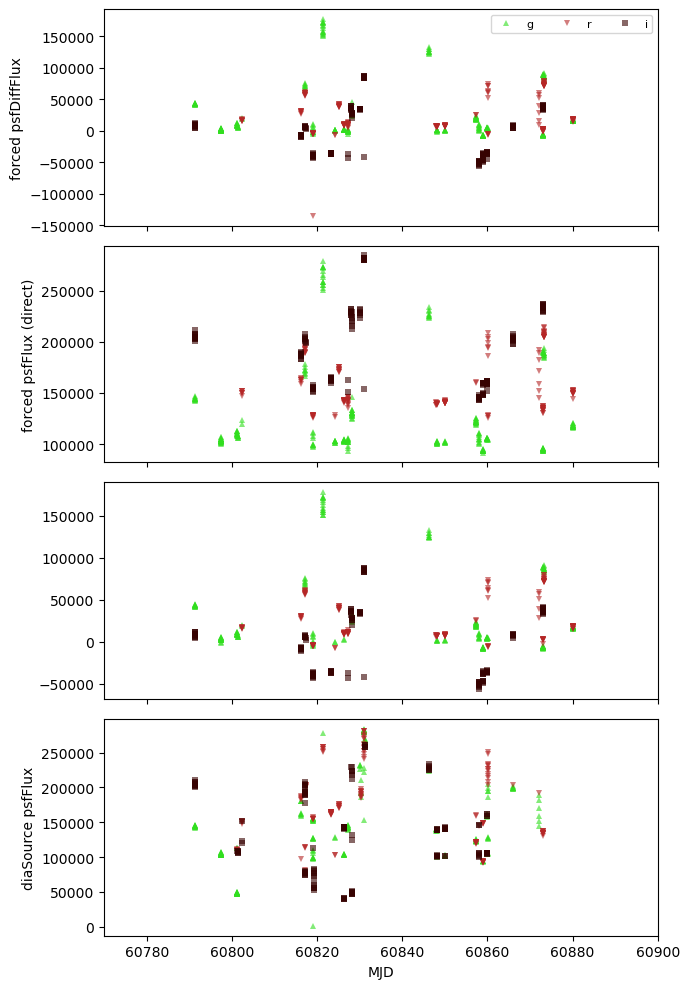

In [84]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(7, 10), sharex=True)
for band in 'gri':
    p1 = (fs_lc['band'] == band) & diff_okflag
    p2 = (fs_lc['band'] == band) & science_okflag
    p3 = (ds_lc['band'] == band)
    p4 = (ds_lc['band'] == band) & diff_okflag & suspect_okflag
    ax1.plot(fs_lc['midpointMjdTai'][p1], fs_lc['psfDiffFlux'][p1],
             filter_symbols[band], color=filter_colors[band], ms=5, mew=0, alpha=0.6, label=band)
    ax2.plot(fs_lc['midpointMjdTai'][p2], fs_lc['psfFlux'][p2],
             filter_symbols[band], color=filter_colors[band], ms=5, mew=0, alpha=0.6)
    ax3.plot(ds_lc['midpointMjdTai'][p3], ds_lc['psfFlux'][p3],
             filter_symbols[band], color=filter_colors[band], ms=5, mew=0, alpha=0.6)
    ax4.plot(fs_lc['midpointMjdTai'][p4], fs_lc['psfFlux'][p4],
             filter_symbols[band], color=filter_colors[band], ms=5, mew=0, alpha=0.6)
ax1.set_ylabel('forced psfDiffFlux'); ax2.set_ylabel('forced psfFlux (direct)')
ax4.set_ylabel('diaSource psfFlux'); ax4.set_xlabel('MJD')
ax4.set_xlim(60770,60900)
ax1.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

Phase-fold on the known period.

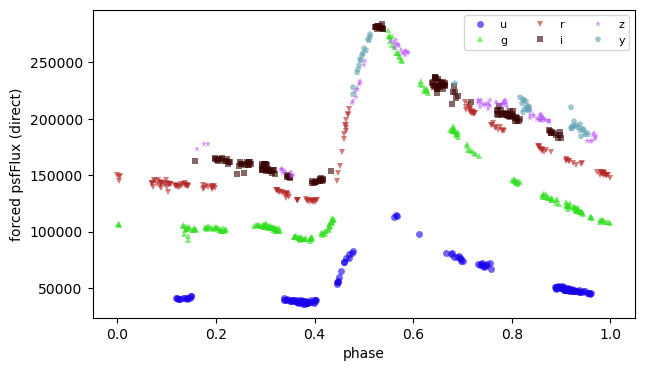

In [87]:
pickr = fs_lc['band'] == 'r'
t0 = fs_lc['midpointMjdTai'][pickr][np.argmax(fs_lc['psfFlux'][pickr])]
phase = np.mod((fs_lc['midpointMjdTai'] - t0) / star_period, 1.0)

fig, ax = plt.subplots(figsize=(7, 4))
for band in filter_names:
    p = (fs_lc['band'] == band) & science_okflag
    ax.plot(phase[p], fs_lc['psfFlux'][p], filter_symbols[band],
            color=filter_colors[band], ms=5, mew=0, alpha=0.6, label=band)
ax.set_xlabel('phase'); ax.set_ylabel('forced psfFlux (direct)')
ax.legend(ncol=3, fontsize=8)
plt.show()

#### 7. Quality flags and extendedness

**Extendedness (star/galaxy separation):** `refExtendedness` = 0 (point-like) if `cModelFlux * 0.985 < psfFlux`, else 1 (extended). Per-band: `<f>_extendedness`. Float measurement: `<f>__sizeExtendedness` and `<f>__model_extendedness`.

**Recommended flags from https://dp2.lsst.io/products/flags/flag_recommendations.html:**
`Object` table:

```
WHERE f_psfFlux_flag = 0                  -- PSF flux succeeded 
  AND f_pixelFlags_saturatedCenter = 0     -- No saturation at center
  AND f_pixelFlags_crCenter = 0            -- No cosmic ray at center
  AND f_pixelFlags_interpolatedCenter = 0  -- No interpolation at center
  AND f_pixelFlags_sensor_edgeCenter = 0   -- Not on detector edge
  AND f_invalidPsfFlag = 0                 -- Valid PSF model
```

For galaxies:
```
  AND f_cModel_flag = 0        -- CModel fit succeeded
  AND f_extendedness = 1       -- Extended source (galaxy)
  AND f_extendedness_flag = 0  -- Classification valid
```

For stars:
```
  AND f_extendedness = 0       -- Point source (star)
  AND f_extendedness_flag = 0  -- Classification valid
```

**Blendedness:** `<f>_blendedness` = 1 − f_child/f_parent; `detect_fromBlend`, `parentObjectId` track deblend lineage.

In [88]:
flag_cols = []
for b in "gr":
    flag_cols += [f"{b}_psfFlux_flag", f"{b}_pixelFlags_saturatedCenter", f"{b}_pixelFlags_crCenter",
                  f"{b}_pixelFlags_interpolatedCenter", f"{b}_pixelFlags_sensor_edgeCenter",
                  f"{b}_invalidPsfFlag", f"{b}_cModel_flag", f"{b}_extendedness_flag"]

cmd_cat = lsdb.open_catalog(lsdb_base / "object_collection",
                           columns=["objectId", "coord_ra", "coord_dec", "g_psfMag",
                                    "r_psfMag", "refExtendedness"] + flag_cols)
cmd_df = cmd_cat.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=0.2 * 3600).compute()
# faint sources near the noise floor give unphysical psfMag tails -- cut on magnitude
cmd_df = cmd_df.query("16 < g_psfMag < 24 and 16 < r_psfMag < 24").dropna(subset=['refExtendedness'])

Computing Catalog:   0%|          | 0/16 [00:00<?, ?it/s]

Build `clean` per the recommendations above.

In [89]:
general_ok = np.ones(len(cmd_df), dtype=bool)
for b in "gr":
    general_ok &= (~cmd_df[f"{b}_psfFlux_flag"]) & (~cmd_df[f"{b}_pixelFlags_saturatedCenter"]) \
                & (~cmd_df[f"{b}_pixelFlags_crCenter"]) & (~cmd_df[f"{b}_pixelFlags_interpolatedCenter"]) \
                & (~cmd_df[f"{b}_pixelFlags_sensor_edgeCenter"]) & (~cmd_df[f"{b}_invalidPsfFlag"])

is_gal = (cmd_df['refExtendedness'] == 1).to_numpy()
class_ok = np.where(is_gal, (~cmd_df['r_cModel_flag']).to_numpy() & (~cmd_df['r_extendedness_flag']).to_numpy(),
                            (~cmd_df['r_extendedness_flag']).to_numpy())
cmd_df['clean'] = general_ok.to_numpy() & class_ok

stars = (cmd_df['refExtendedness'] == 0).to_numpy()
gals = is_gal
clean = cmd_df['clean'].to_numpy()
print(f"stars: {stars.sum()} ({(stars & clean).sum()} clean, {(stars & ~clean).sum()} flagged)")
print(f"gals:  {gals.sum()} ({(gals & clean).sum()} clean, {(gals & ~clean).sum()} flagged)")

stars: 7835 (7567 clean, 268 flagged)
gals:  5427 (4807 clean, 620 flagged)


Side by side: all objects (flagged marked) vs. clean only.

Clean cut removes ~7%, scattered.

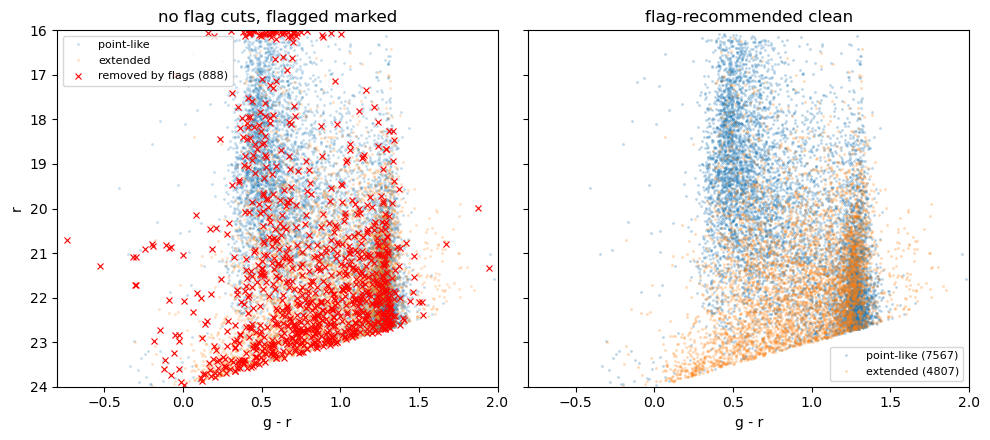

In [90]:
gr = (cmd_df['g_psfMag'] - cmd_df['r_psfMag']).to_numpy()
rmag = cmd_df['r_psfMag'].to_numpy()
removed = (stars | gals) & ~clean

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
axes[0].plot(gr[stars], rmag[stars], 'o', ms=2, mew=0, alpha=0.25, color='C0', label='point-like')
axes[0].plot(gr[gals], rmag[gals], 'o', ms=2, mew=0, alpha=0.25, color='C1', label='extended')
axes[0].plot(gr[removed], rmag[removed], 'x', ms=4, mew=0.8, color='red',
            label=f'removed by flags ({removed.sum()})')
axes[0].set_xlabel('g - r'); axes[0].set_title('no flag cuts, flagged marked')
axes[0].set_xlim(-0.8, 2); axes[0].legend(fontsize=8)

axes[1].plot(gr[stars & clean], rmag[stars & clean], 'o', ms=2, mew=0, alpha=0.3, color='C0',
            label=f'point-like ({(stars & clean).sum()})')
axes[1].plot(gr[gals & clean], rmag[gals & clean], 'o', ms=2, mew=0, alpha=0.3, color='C1',
            label=f'extended ({(gals & clean).sum()})')
axes[1].set_xlabel('g - r'); axes[1].set_title('flag-recommended clean')
axes[1].set_xlim(-0.8, 2); axes[1].legend(fontsize=8)

axes[0].set_ylabel('r'); axes[0].set_ylim(24, 16)
plt.tight_layout()
plt.show()

One clean + one flagged example per class -- coadd + mask cutouts.

In [91]:
r_pixel_bad = (cmd_df['r_pixelFlags_saturatedCenter'] | cmd_df['r_pixelFlags_crCenter']
              | cmd_df['r_pixelFlags_interpolatedCenter'] | cmd_df['r_pixelFlags_sensor_edgeCenter']).to_numpy()

vis = ((cmd_df['r_psfMag'] > 18) & (cmd_df['r_psfMag'] < 21)).to_numpy()
selections = {
    "star, clean": stars & ~r_pixel_bad & vis,
    "star, flagged": stars & r_pixel_bad,
    "galaxy, clean": gals & ~r_pixel_bad & vis,
    "galaxy, flagged": gals & r_pixel_bad,
}
examples = {}
for name, sel in selections.items():
    row = cmd_df[sel].sort_values('r_psfMag').iloc[0]  # brightest match
    examples[name] = (row['coord_ra'], row['coord_dec'], row['r_psfMag'])
    print(f"{name}: objectId={row['objectId']}  r={row['r_psfMag']:.2f}")

star, clean: objectId=744858242361859742  r=18.00
star, flagged: objectId=744858173642387432  r=16.00
galaxy, clean: objectId=744858242361861614  r=18.03
galaxy, flagged: objectId=744858242361859181  r=16.03


In [92]:
import io
from lsst.rsp.utils import get_pyvo_auth
from pyvo.dal.adhoc import SodaQuery

def get_cutout_exposure(ra, dec, fov_deg, band='r'):
    res = sia.search(pos=(ra, dec, fov_deg), calib_level=3, dpsubtype='lsst.deep_coadd')
    tx = np.where(np.array(res['lsst_band']) == band)[0]
    rec = res.getrecord(int(tx[0]))
    dl = discovery.get_datalink_results(rec)
    sq = SodaQuery.from_resource(dl, dl.get_adhocservice_by_id("cutout-sync-exposure"),
                                 session=get_pyvo_auth())
    sq.circle = (ra, dec, fov_deg)
    cutout_bytes = sq.execute_stream().read()
    sq.raise_if_error()
    return read_archive(io.BytesIO(cutout_bytes))

cutout_fov = 0.0033  # deg, ~12 arcsec radius postage stamp
cutouts = {name: get_cutout_exposure(ra, dec, cutout_fov) for name, (ra, dec, mag) in examples.items()}

`afw_display` misbehaves on dense small-panel grids -- `imshow` + shared WCS extent instead, `mask.get()` per plane.

`+` marks the target.

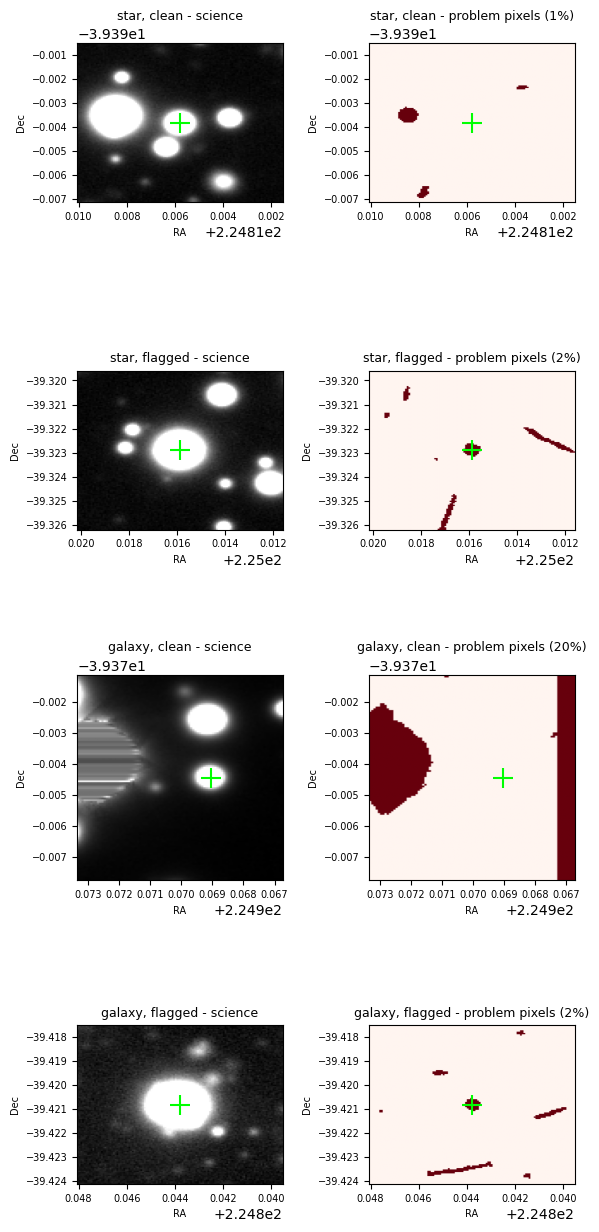

In [93]:
OBJECT_FLAG_PLANES = ["SATURATED", "COSMIC_RAY", "INTERPOLATED", "DETECTION_EDGE"]

fig, axes = plt.subplots(4, 2, figsize=(6, 13))
for row, (name, cut) in enumerate(cutouts.items()):
    ra, dec, mag = examples[name]
    bbox, sky = cut.bbox, cut.sky_projection
    c00 = sky.pixel_to_sky(x=bbox.x.min, y=bbox.y.min)
    c10 = sky.pixel_to_sky(x=bbox.x.max, y=bbox.y.min)
    c01 = sky.pixel_to_sky(x=bbox.x.min, y=bbox.y.max)
    ext = (c00.ra.degree, c10.ra.degree, c00.dec.degree, c01.dec.degree)

    arr = cut.image.array
    norm = ImageNormalize(arr, interval=ZScaleInterval(), stretch=LinearStretch())
    axes[row, 0].imshow(arr, origin='lower', cmap='gray', extent=ext, norm=norm)
    axes[row, 0].plot(ra, dec, '+', ms=14, mew=1.5, color='lime')
    axes[row, 0].set_title(f"{name} - science", fontsize=9)

    cmask = cut.mask
    flagged = np.zeros(cmask.bbox.shape, dtype=bool)
    for plane in OBJECT_FLAG_PLANES:
        flagged |= cmask.get(plane)
    axes[row, 1].imshow(flagged, origin='lower', cmap='Reds', extent=ext, vmin=0, vmax=1)
    axes[row, 1].plot(ra, dec, '+', ms=14, mew=1.5, color='lime')
    axes[row, 1].set_title(f"{name} - problem pixels ({flagged.mean():.0%})", fontsize=9)

    for ax in axes[row]:
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
        ax.tick_params(labelsize=7)
        ax.set_xlabel("RA", fontsize=7); ax.set_ylabel("Dec", fontsize=7)
plt.tight_layout()
plt.show()